# Introduction to Data Science: Interpreting Data

Please follow the instructions and uncomment the skeleton code as necessary.

This assignment is due in addition to the small group assignment before the next class

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Below is what is called a scatter plot. It takes two inputs, $x$ and $y$, and plots them out on a graph. 

Now, let's look at the data: What is the general shape? Although the points are not in a perfectly straight line, there is certainly a shape to the data. This general shape is what's called a **trend**, and the deviation from that trend is called **noise**.  

One of the tasks of data science is to find the most accurate trendline given some amout of noise. 

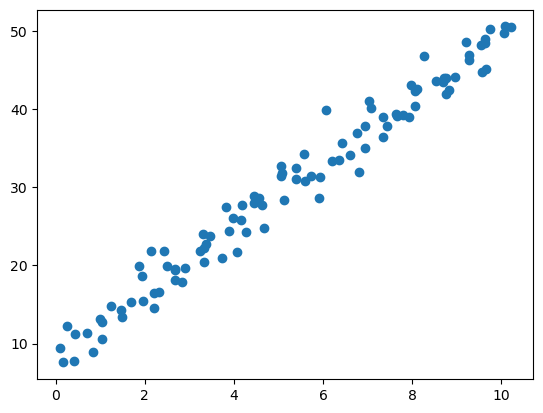

In [3]:
x,y = np.loadtxt('./data/scatter_data.txt', unpack=True)
plt.scatter(x, y)
plt.show()

Since the data is a little noisy, we won't be able to make a line that perfectly lands on every point. However, we can calculate the degree of accuracy of our line and try to minimize the error. 

Let's try to guess a trendline! Change the `slope` and `intercept` variables until the red line is aligned with the trend of the data. For practice, try to get the error below three!

Try to get this error number below 3:  22.81


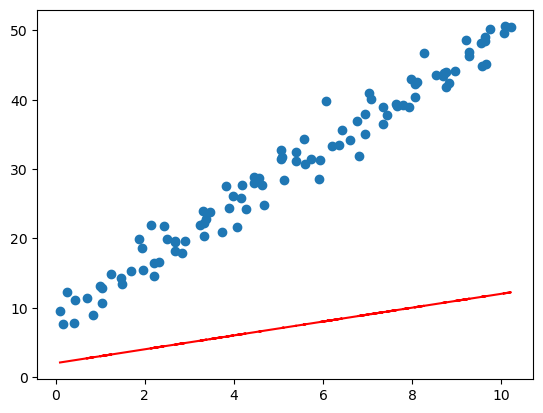

In [4]:
slope = 1           # Change this to a different number
intercept = 2       # Change this too and try to reduce the error value!

line_function = lambda x: x*slope + intercept
line_of_fit = [line_function(point) for point in x]
error = line_of_fit - y                                  # Calculate the difference from expected value
mean_error = (abs(line_of_fit-y)).mean()                 # check for the mean error

plt.scatter(x, y)
plt.plot(x,line_of_fit,'r-') 
print(f'Try to get this error number below 3: {mean_error : .2f}')
plt.show()

Now, oftentimes the data we're looking at doesn't follow a straight line. When it doesn't, there are a variety of mathematical expressions that could describe a line through the data. The class of expressions that we'll be looking at in this module are called polynomials. Polynomials are sums of variables multiplied by coefficients with natural number exponents. The degreee of a polynomial is the number of highest exponent. 

So a polynomial like this: 

$-x^3 + 5x^2 - 10x + 6$ 

has coefficients of $-1$, $5$, $-10$ and $6$. Its degree is $3$, as its highest exponent is $3$. 

Try experimenting with making different polynomial functions:

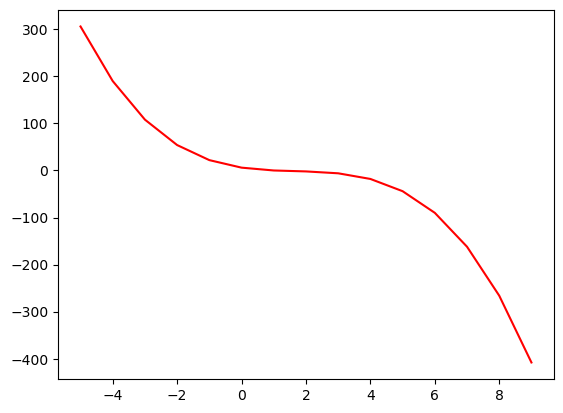

In [5]:
your_polynomial = lambda x: -x**3 + 5*x**2 - 10*x + 6 # Change these numbers for a different looking curve
plot_start = -5
plot_end = 10
x = np.arange(plot_start,plot_end)
plt.plot(x, your_polynomial(x),'r-')
plt.show()

Now that you're familiar with polynomial functions, let's use them to fit some data. Below is a more complicated scatter plot.

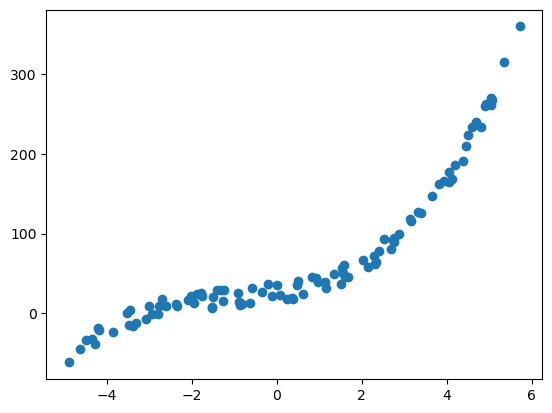

In [10]:
x,y = np.loadtxt('./data/poly_data.txt', unpack=True)
plt.scatter(x, y)
plt.show()

### Q.1 Please describe the plot above in 1-2 sentences

### begins with increasing and then goes "flat" for a little, then increases more rapidly

### Q.2 Guess the degree of a polynomial that might fit the plot and describe your reasoning in 1-2 sentences

### A.2 most likely 3rd degree polynomail since there is 1 point of inflection 


Now that you've made a guess as to the polynomial degree, we can use a function in numpy called `numpy.polyfit` to test it out! 

Change the degree variable to your guess and see how well the line fits the data:

Mean error: 6.44


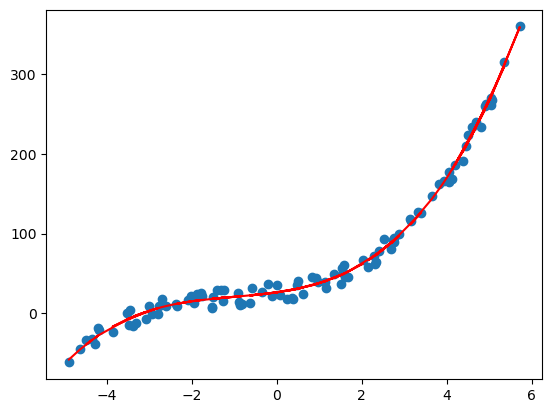

In [4]:
degree = 3
import numpy as np
import matplotlib.pyplot as plt
x,y = np.loadtxt('./data/poly_data.txt', unpack=True)

fit_line = np.polyval(np.polyfit(x,y,degree),x)
print(f'Mean error: {abs(fit_line-y).mean():.2f}')
plt.plot(x,fit_line,'r-')
plt.scatter(x, y)
plt.show()

### Q.3 How good was your fit? Describe in 1-2 sentences.

### A.3 The fit was very good, almost close to perfect, as the line aligns well with the scatter plot and the mean error is only 6.44, a low number in comparison to the previous mean error

Note that although there is a polynomial degree to suffieciently fit the curve, one can also input a higher degree and get a slightly better result. Try putting in a higher number than your guess.

Mean error: 6.44


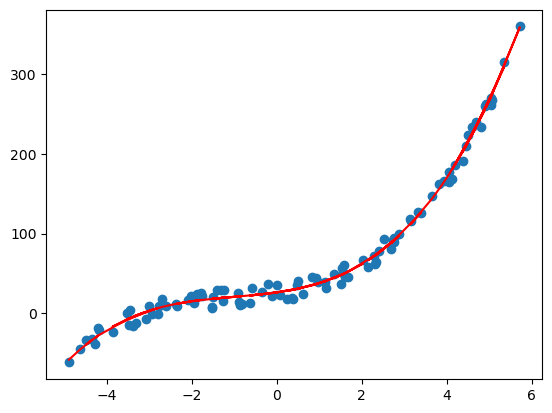

In [5]:
degree = 4

fit_line = np.polyval(np.polyfit(x,y,degree),x)
print(f'Mean error: {abs(fit_line-y).mean():.2f}')
plt.plot(x,fit_line,'r-')
plt.scatter(x, y)
plt.show()

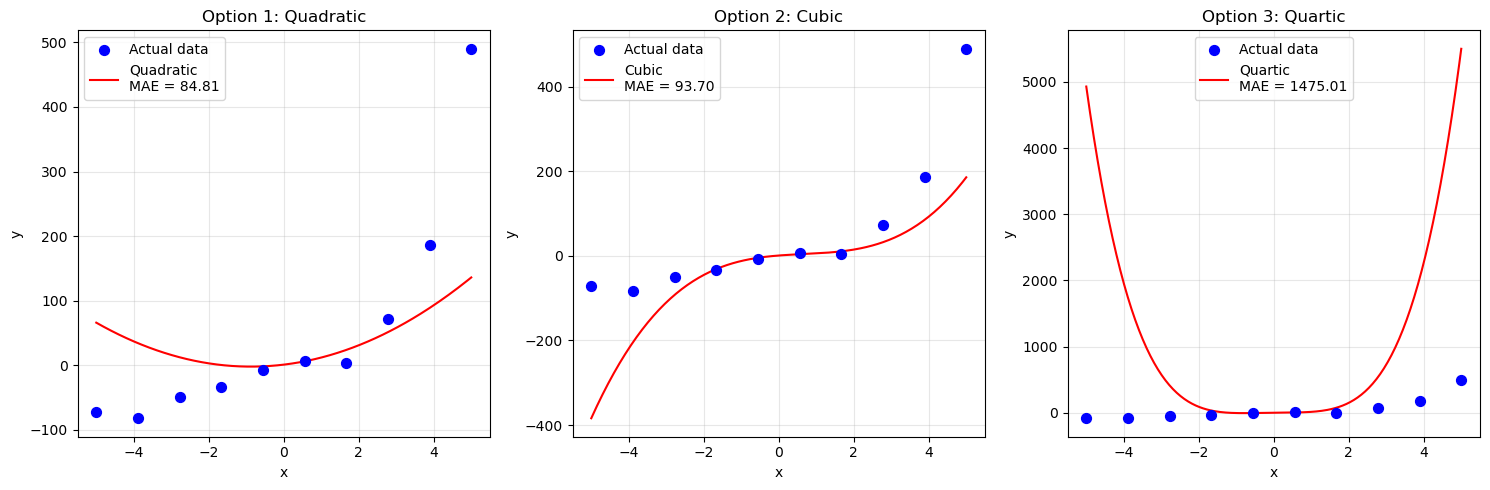

Mean Absolute Errors:
Quadratic (Option 1): 84.81
Cubic (Option 2): 93.70
Quartic (Option 3): 1475.01

Best fit: Option 1 (lowest MAE)


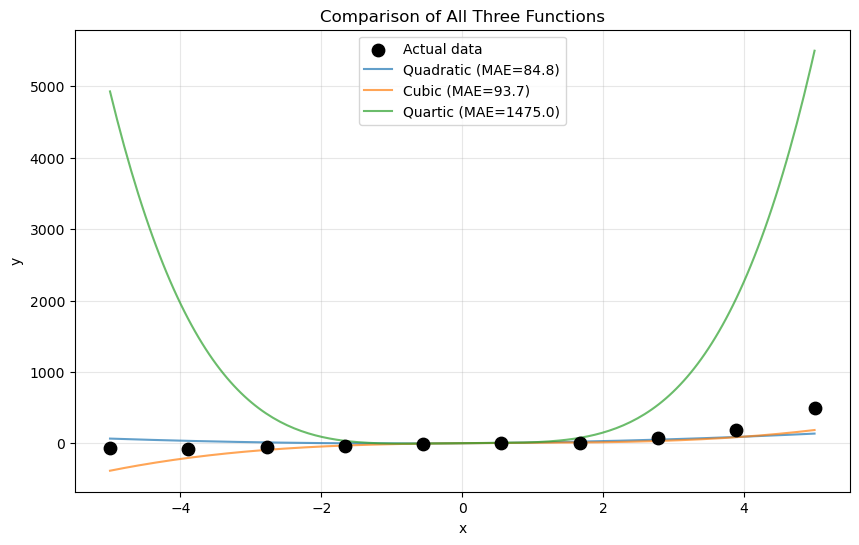

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Given data
x = np.linspace(-5, 5, 10)
y_actual = np.array([-72, -82, -49, -33, -8, 7, 4, 72, 186, 490])

# Define the three candidate functions
def f1(x):
    return 4*x**2 + 7*x + 1

def f2(x):
    return 2*x**3 - 4*x**2 + 7*x + 1

def f3(x):
    return 8.5*x**4 + 2*x**3 - 4*x**2 + 7*x + 1

# Create smooth x values for plotting curves
x_smooth = np.linspace(-5, 5, 200)

# Calculate predictions and errors
y1_pred = f1(x)
y2_pred = f2(x)
y3_pred = f3(x)

# Calculate mean absolute error for each
mae1 = np.mean(np.abs(y_actual - y1_pred))
mae2 = np.mean(np.abs(y_actual - y2_pred))
mae3 = np.mean(np.abs(y_actual - y3_pred))

# Create the plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Quadratic
axes[0].scatter(x, y_actual, color='blue', s=50, label='Actual data', zorder=5)
axes[0].plot(x_smooth, f1(x_smooth), color='red', label=f'Quadratic\nMAE = {mae1:.2f}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Option 1: Quadratic')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Cubic
axes[1].scatter(x, y_actual, color='blue', s=50, label='Actual data', zorder=5)
axes[1].plot(x_smooth, f2(x_smooth), color='red', label=f'Cubic\nMAE = {mae2:.2f}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Option 2: Cubic')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Quartic
axes[2].scatter(x, y_actual, color='blue', s=50, label='Actual data', zorder=5)
axes[2].plot(x_smooth, f3(x_smooth), color='red', label=f'Quartic\nMAE = {mae3:.2f}')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Option 3: Quartic')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("Mean Absolute Errors:")
print(f"Quadratic (Option 1): {mae1:.2f}")
print(f"Cubic (Option 2): {mae2:.2f}")
print(f"Quartic (Option 3): {mae3:.2f}")
print()
print(f"Best fit: Option {np.argmin([mae1, mae2, mae3]) + 1} (lowest MAE)")

# Also plot all three on one graph for comparison
plt.figure(figsize=(10, 6))
plt.scatter(x, y_actual, color='black', s=80, label='Actual data', zorder=5)
plt.plot(x_smooth, f1(x_smooth), label=f'Quadratic (MAE={mae1:.1f})', alpha=0.7)
plt.plot(x_smooth, f2(x_smooth), label=f'Cubic (MAE={mae2:.1f})', alpha=0.7)
plt.plot(x_smooth, f3(x_smooth), label=f'Quartic (MAE={mae3:.1f})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of All Three Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Although this curve is ever so slightly more accurate to the data, it may be a less useful curve. In fact, it may be an example of what is called **overfitting**. 

Overfitting is an abstract kind of error but is beyond the scope of this module. You can read more about it [here](https://en.wikipedia.org/wiki/Overfitting)!